# Linear Regression Model - 2

This notebook is the training and development of the linear regression model. The purpose of this model is to establish a baseline performance for the other models. This notebook is for the wind, weather, and water dataset.

In [23]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np 
from sklearn.metrics import  r2_score
from pathlib import Path
import matplotlib.pyplot as plt
import joblib
import matplotlib.dates as mdates

### Weather, water, and wind dataset

In [24]:
data_folder = Path(r'..\data\model-ready\water-weather-wind')
if not data_folder.exists():
    raise ValueError('Data folder does not exists: ', data_folder)

##### read in our model ready data

In [25]:
# train
train_X_df = pd.read_parquet(data_folder / 'scaled-X-train.parquet')
train_y_df = pd.read_parquet(data_folder / 'Y-train.parquet') # the Y data is not actually scaled inspite of the name

# test
test_X_df = pd.read_parquet(data_folder / 'scaled-X-test.parquet')
test_y = pd.read_parquet(data_folder / 'Y-test.parquet') # the Y data is not actually scaled inspite of the name

# val
val_X_df = pd.read_parquet(data_folder / 'scaled-X-val.parquet')
val_y = pd.read_parquet(data_folder / 'Y-val.parquet') # the Y data is not actually scaled inspite of the name



In [26]:
scaler = joblib.load(data_folder / 'minmax_scaler.joblib')

##### train the model

In [27]:
model = LinearRegression()
model.fit(train_X_df, train_y_df)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 24)","[[ 0.48, 0.49, 0.06,...,-0.37, 0.08, 0.8 ]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](24,)","['WSPD','WDIR','TMAX',...,'past_10_day_std_temp','wind_u_3day_ave', 'wind_v_3day_ave']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[12.02]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,24
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(22)


#### evaluate on validation and test dataset
The two sets are combined here, as the validation set it truly needed for training nueral networks, where a validation set is used to prevent overfitting.

In [28]:
test_val_x = pd.concat([test_X_df, val_X_df], ignore_index=True)
test_val_y = pd.concat([test_y, val_y], ignore_index=True)

In [29]:
y_pred = model.predict(test_val_x)

In [30]:
test_val_x_unscaled = scaler.inverse_transform(test_val_x)

In [31]:
test_val_x = pd.DataFrame(columns=test_val_x.columns, data=test_val_x_unscaled)

In [32]:
test_val_x.head(1)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,sin_day,cos_day,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave
0,2.913043,259.130435,75.0,66.0,0.0,20.3,21.8,8.0,17.0,2005.0,...,-0.299363,-0.954139,-0.982059,-0.188574,-2.860781,-0.549324,22.0,0.516398,-1.81386,-1.465904


In [33]:
test_val_x['date'] = pd.to_datetime(test_val_x[['year','month','day']], errors='coerce')

In [34]:
test_val_x.head(1)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,cos_day,sin_wdir,cos_wdir,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,date
0,2.913043,259.130435,75.0,66.0,0.0,20.3,21.8,8.0,17.0,2005.0,...,-0.954139,-0.982059,-0.188574,-2.860781,-0.549324,22.0,0.516398,-1.81386,-1.465904,2005-08-17


In [35]:
test_val_x['prediction'] = y_pred

In [36]:
test_val_x['target'] = test_val_y

In [37]:
errors = y_pred - test_val_y
test_val_x['errors'] = errors

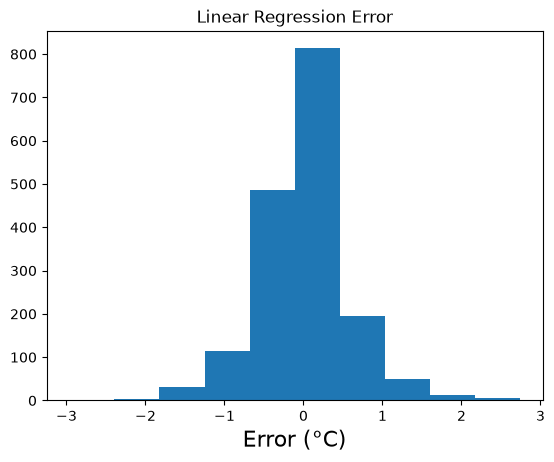

In [38]:
plt.hist(errors)
plt.title('Linear Regression Error')
plt.xlabel('Error (\u00b0C)', fontsize=16)
plt.show()

In [39]:
test_val_x.head(20)

,WSPD,WDIR,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,...,wind_u,wind_v,past_10_day_ave_temp,past_10_day_std_temp,wind_u_3day_ave,wind_v_3day_ave,date,prediction,target,errors
0,2.913043,259.130435,75.0,66.0,0.00,20.3,21.8,8.0,17.0,2005.0,...,-2.860781,-0.549324,22.000000,0.516398,-1.813860,-1.465904,2005-08-17,21.871183,21.8,0.071183
1,2.869565,289.565217,75.0,66.0,0.00,21.8,22.2,8.0,18.0,2005.0,...,-2.703879,0.960959,21.950000,0.462481,-2.257916,-0.482370,2005-08-18,22.128379,21.8,0.328379
2,2.625000,207.916667,75.0,64.0,0.00,21.6,21.6,8.0,19.0,2005.0,...,-1.228991,-2.319527,21.840000,0.389301,-2.264550,-0.635964,2005-08-19,21.810378,22.2,-0.389622
3,3.291667,237.500000,74.0,65.0,0.00,21.4,21.7,8.0,20.0,2005.0,...,-2.776164,-1.768611,21.740000,0.245855,-2.236344,-1.042393,2005-08-20,21.797000,21.6,0.197000
4,3.391304,324.782609,74.0,65.0,0.00,20.8,20.8,8.0,21.0,2005.0,...,-1.955698,2.770594,21.620000,0.367575,-1.986951,-0.439182,2005-08-21,21.269204,21.7,-0.430796
5,2.333333,253.333333,74.0,64.0,0.00,21.1,21.1,8.0,22.0,2005.0,...,-2.235309,-0.669208,21.570000,0.402906,-2.322390,0.110925,2005-08-22,21.409174,20.8,0.609174
6,1.833333,181.250000,71.0,62.0,0.00,16.5,19.4,8.0,23.0,2005.0,...,-0.039994,-1.832897,21.380000,0.798332,-1.410334,0.089496,2005-08-23,20.425792,21.1,-0.674208
7,1.136364,165.909091,75.0,63.0,0.00,17.1,19.5,8.0,24.0,2005.0,...,0.276660,-1.102171,21.150000,0.975534,-0.666214,-1.201425,2005-08-24,20.179984,19.4,0.779984
8,3.000000,241.666667,72.0,64.0,0.00,20.1,20.2,9.0,16.0,2005.0,...,-2.640604,-1.423801,20.200000,0.000000,0.237007,-1.235129,2005-09-16,20.270797,20.2,0.070797
9,2.166667,247.083333,72.0,64.0,0.00,19.3,20.5,9.0,17.0,2005.0,...,-1.995656,-0.843682,20.300000,0.173205,-0.507214,-1.104647,2005-09-17,20.406229,20.2,0.206229


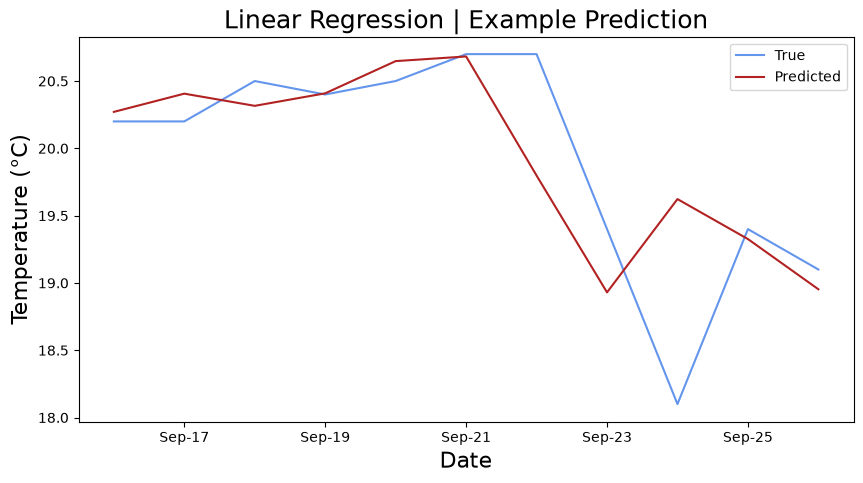

In [40]:
plot_df = test_val_x[8:19].copy()
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(plot_df.date, plot_df.target, label='True', color='cornflowerblue')
ax.plot(plot_df.date, plot_df.prediction, label='Predicted', color='firebrick')
ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
ax.set_xlabel('Date', fontsize=16)
ax.set_title('Linear Regression | Example Prediction', fontsize=18)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.show()

In [41]:
errors

,target
0,0.071183
1,0.328379
2,-0.389622
3,0.197000
4,-0.430796
...,...
1708,0.355050
1709,-0.037623
1710,-0.009714
1711,-0.038695


In [42]:
mse = np.mean([x**2 for x in errors.target])
rmse = np.sqrt(mse)
r_2 = r2_score(test_val_y, y_pred)

print(f'RMSE = {round(rmse, 2)}')
print(f'r2 score = {round(r_2, 2)}')

RMSE = 0.56
r2 score = 0.96


##### Baseline RMSE and R2 Score are 0.56 and 0.96 respectively. These results are quite similar to the larger dataset without wind.